In [1]:
from google.colab import files

uploaded = files.upload()

Saving soil-nutrient-gap-prediction-for-sustainable-maize.zip to soil-nutrient-gap-prediction-for-sustainable-maize.zip


In [2]:
import zipfile
import os

zip_path = "soil-nutrient-gap-prediction-for-sustainable-maize.zip"
extract_path = "soil_nutrient_gap"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [3]:
for root, dirs, files in os.walk(extract_path):
    for file in files:
        print(os.path.join(root, file))

soil_nutrient_gap/Soil Nutrient/Gap_Test.csv
soil_nutrient_gap/Soil Nutrient/Test.csv
soil_nutrient_gap/Soil Nutrient/VariableDefinitions.csv
soil_nutrient_gap/Soil Nutrient/Gap_Train.csv
soil_nutrient_gap/Soil Nutrient/SampleSubmission.csv
soil_nutrient_gap/Soil Nutrient/Train.csv


In [4]:
import pandas as pd

train_path = "soil_nutrient_gap/Soil Nutrient/Train.csv"

train_df = pd.read_csv(train_path)

print("Shape:", train_df.shape)
print("\nColumns:")
print(train_df.columns.tolist())

print("\nFirst 5 rows:")
display(train_df.head())

Shape: (7744, 44)

Columns:
['site', 'PID', 'lon', 'lat', 'pH', 'alb', 'bio1', 'bio12', 'bio15', 'bio7', 'bp', 'cec20', 'dows', 'ecec20', 'hp20', 'ls', 'lstd', 'lstn', 'mb1', 'mb2', 'mb3', 'mb7', 'mdem', 'para', 'parv', 'ph20', 'slope', 'snd20', 'soc20', 'tim', 'wp', 'xhp20', 'BulkDensity', 'N', 'P', 'K', 'Ca', 'Mg', 'S', 'Fe', 'Mn', 'Zn', 'Cu', 'B']

First 5 rows:


,site,PID,lon,lat,pH,alb,bio1,bio12,bio15,bio7,...,P,K,Ca,Mg,S,Fe,Mn,Zn,Cu,B
0,site_id_bIEHwl,ID_I5RGjv,70.603761,46.173798,7.75,176,248,920,108,190,...,0.34,147,6830,2310,5.66,75.2,85.0,0.82,2.98,0.24
1,site_id_nGvnKc,ID_8jWzJ5,70.590479,46.078924,7.10,181,250,1080,113,191,...,11.70,151,1180,235,19.40,96.2,409.0,2.57,4.32,0.10
2,site_id_nGvnKc,ID_UgzkN8,70.582553,46.048820,6.95,188,250,1109,111,191,...,21.80,151,1890,344,11.00,76.7,65.0,1.95,1.24,0.22
3,site_id_nGvnKc,ID_DLLHM9,70.573267,46.021910,7.83,174,250,1149,112,191,...,39.90,201,6660,719,14.90,81.9,73.0,4.90,3.08,0.87
4,site_id_7SA9rO,ID_d009mj,70.585330,46.204336,8.07,188,250,869,114,191,...,1.00,90,7340,1160,8.66,69.4,149.0,0.55,3.03,0.31


In [5]:
gap_train_path = "soil_nutrient_gap/Soil Nutrient/Gap_Train.csv"

gap_train_df = pd.read_csv(gap_train_path)

print("Shape:", gap_train_df.shape)

print("\nColumns:")
print(gap_train_df.columns.tolist())

print("\nFirst 10 rows:")
display(gap_train_df.head(10))

Shape: (85184, 5)

Columns:
['Nutrient', 'Required', 'Available', 'Gap', 'PID']

First 10 rows:


,Nutrient,Required,Available,Gap,PID
0,N,100.0,3796.0000,-3696.0000,ID_I5RGjv
1,P,40.0,0.9928,39.0072,ID_I5RGjv
2,K,52.0,429.2400,-377.2400,ID_I5RGjv
3,Ca,12.0,19943.6000,-19931.6000,ID_I5RGjv
4,Mg,8.0,6745.2000,-6737.2000,ID_I5RGjv
5,S,12.0,16.5272,-4.5272,ID_I5RGjv
6,Fe,0.8,219.5840,-218.7840,ID_I5RGjv
7,Mn,0.4,248.2000,-247.8000,ID_I5RGjv
8,Zn,0.4,2.3944,-1.9944,ID_I5RGjv
9,Cu,0.2,8.7016,-8.5016,ID_I5RGjv


In [6]:
print("Nutrient counts:")
print(gap_train_df["Nutrient"].value_counts())

print("\nGap statistics:")
display(gap_train_df["Gap"].describe())

print("\nPositive / Negative / Zero gaps:")
print("Positive:", (gap_train_df["Gap"] > 0).sum())
print("Negative:", (gap_train_df["Gap"] < 0).sum())
print("Zero:", (gap_train_df["Gap"] == 0).sum())

Nutrient counts:
Nutrient
N     7744
P     7744
K     7744
Ca    7744
Mg    7744
S     7744
Fe    7744
Mn    7744
Zn    7744
Cu    7744
B     7744
Name: count, dtype: int64

Gap statistics:


,Gap
count,85184.000000
mean,-1901.286245
std,4759.598522
min,-83460.000000
25%,-1484.755000
50%,-214.760000
75%,-4.238650
max,100.000000



Positive / Negative / Zero gaps:
Positive: 6780
Negative: 78396
Zero: 8


In [7]:
print("Missing values:")
print(train_df.isnull().sum())

print("\nData types:")
print(train_df.dtypes)

print("\nDuplicate rows:", train_df.duplicated().sum())

Missing values:
site           0
PID            0
lon            0
lat            0
pH             0
alb            0
bio1           0
bio12          0
bio15          0
bio7           0
bp             0
cec20          0
dows           0
ecec20         5
hp20           5
ls             0
lstd           0
lstn           0
mb1            0
mb2            0
mb3            0
mb7            0
mdem           0
para           0
parv           0
ph20           0
slope          0
snd20          0
soc20          0
tim            0
wp             0
xhp20          5
BulkDensity    4
N              0
P              0
K              0
Ca             0
Mg             0
S              0
Fe             0
Mn             0
Zn             0
Cu             0
B              0
dtype: int64

Data types:
site            object
PID             object
lon            float64
lat            float64
pH             float64
alb              int64
bio1             int64
bio12            int64
bio15            int64
bio

In [8]:
var_path = "soil_nutrient_gap/Soil Nutrient/VariableDefinitions.csv"

var_df = pd.read_csv(var_path)

print("Shape:", var_df.shape)
print("\nColumns:")
print(var_df.columns.tolist())

display(var_df.head(20))

Shape: (121, 2)

Columns:
['Variable name', 'Description']


,Variable name,Description
0,site,Unique identifier of the site/farm
1,PID,Unique identifier of the soil sample site
2,pH,"Soil pH level, indicating acidity or alkalinity"
3,N,Nitrogen content in the soil in ppm
4,P,Phosphorus content in the soil in ppm
5,K,Potassium content in the soil in ppm
6,S,Sulfur content in the soil in ppm
7,Ca,Calcium content in the soil in ppm
8,Mg,Magnesium content in the soil in ppm
9,Mn,Manganese content in the soil in ppm


In [9]:
pd.set_option("display.max_rows", 150)
pd.set_option("display.max_colwidth", 100)

display(var_df)

,Variable name,Description
0,site,Unique identifier of the site/farm
1,PID,Unique identifier of the soil sample site
2,pH,"Soil pH level, indicating acidity or alkalinity"
3,N,Nitrogen content in the soil in ppm
4,P,Phosphorus content in the soil in ppm
5,K,Potassium content in the soil in ppm
6,S,Sulfur content in the soil in ppm
7,Ca,Calcium content in the soil in ppm
8,Mg,Magnesium content in the soil in ppm
9,Mn,Manganese content in the soil in ppm


In [10]:
gap_train_df["Calculated_Gap"] = (
    gap_train_df["Required"] - gap_train_df["Available"]
)

print("Does Gap = Required - Available?")
print(
    (gap_train_df["Gap"].round(6) ==
     gap_train_df["Calculated_Gap"].round(6)).all()
)

print("\nMaximum difference:")
print(
    (gap_train_df["Gap"] - gap_train_df["Calculated_Gap"]).abs().max()
)

Does Gap = Required - Available?
True

Maximum difference:
3.637978807091713e-12


In [11]:
gap_by_nutrient = (
    gap_train_df
    .groupby("Nutrient")["Gap"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
)

display(gap_by_nutrient)

,count,mean,std,min,max
Nutrient,,,,,
B,7744,-0.92,0.87,-12.07,0.06
Ca,7744,-13055.80,9543.28,-83460.00,-592.80
Cu,7744,-8.58,7.04,-495.10,0.00
Fe,7744,-341.18,168.45,-1440.20,-18.44
K,7744,-964.61,683.43,-9092.80,11.40
Mg,7744,-2199.02,1452.89,-11078.88,-103.24
Mn,7744,-353.48,180.76,-2080.76,-7.60
N,7744,-3970.99,1733.20,-17288.00,100.00
P,7744,0.40,106.98,-2183.72,39.77


In [12]:
required_available_summary = (
    gap_train_df
    .groupby("Nutrient")[["Required", "Available"]]
    .agg(["mean", "min", "max"])
    .round(2)
)

display(required_available_summary)

Required                 Available                  
             mean     min     max      mean     min       max
Nutrient                                                     
B            0.08    0.08    0.08      1.00    0.02     12.15
Ca          12.00   12.00   12.00  13067.80  604.80  83472.00
Cu           0.20    0.20    0.20      8.78    0.20    495.30
Fe           0.80    0.80    0.80    341.98   19.24   1441.00
K           52.00   52.00   52.00   1016.61   40.60   9144.80
Mg           8.00    8.00    8.00   2207.02  111.24  11086.88
Mn           0.40    0.40    0.40    353.88    8.00   2081.16
N          100.00  100.00  100.00   4070.99    0.00  17388.00
P           40.00   40.00   40.00     39.60    0.23   2223.72
S           12.00   12.00   12.00     27.08    0.66   4976.10
Zn           0.40    0.40    0.40      5.29    0.24    539.66

In [13]:
# Merge Train.csv nutrient values with Gap_Train.csv
merged_df = gap_train_df.merge(
    train_df[["PID", "N", "P", "K", "Ca", "Mg", "S", "Fe", "Mn", "Zn", "Cu", "B"]],
    on="PID",
    how="left"
)

# Calculate correlation between Train nutrient values and Available values
for nutrient in ["N", "P", "K", "Ca", "Mg", "S", "Fe", "Mn", "Zn", "Cu", "B"]:

    temp = merged_df[merged_df["Nutrient"] == nutrient]

    correlation = temp["Available"].corr(temp[nutrient])

    print(f"{nutrient}: correlation = {correlation:.4f}")

N: correlation = 0.9871
P: correlation = 0.9980
K: correlation = 0.9924
Ca: correlation = 0.9954
Mg: correlation = 0.9941
S: correlation = 0.9988
Fe: correlation = 0.9896
Mn: correlation = 0.9877
Zn: correlation = 0.9979
Cu: correlation = 0.9960
B: correlation = 0.9946


In [15]:
import numpy as np

In [16]:
# Check the relationship between Train nutrient values and Gap_Train Available values

nutrients = ["N", "P", "K", "Ca", "Mg", "S", "Fe", "Mn", "Zn", "Cu", "B"]

for nutrient in nutrients:
    temp = merged_df[merged_df["Nutrient"] == nutrient].copy()

    # Linear relationship: Available ≈ a * Train nutrient + b
    slope, intercept = np.polyfit(
        temp[nutrient],
        temp["Available"],
        1
    )

    print(
        f"{nutrient}: "
        f"Available ≈ {slope:.4f} × {nutrient} + {intercept:.4f}"
    )

N: Available ≈ 2.2869 × N + 293.2802
P: Available ≈ 2.5605 × P + -0.3253
K: Available ≈ 2.5577 × K + -18.4631
Ca: Available ≈ 2.6428 × Ca + -482.1375
Mg: Available ≈ 2.5759 × Mg + -38.5698
S: Available ≈ 2.6046 × S + -1.2062
Fe: Available ≈ 2.4474 × Fe + 5.4816
Mn: Available ≈ 2.5627 × Mn + -7.1730
Zn: Available ≈ 2.4297 × Zn + 0.0845
Cu: Available ≈ 2.5281 × Cu + -0.0780
B: Available ≈ 2.5698 × B + -0.0182


In [17]:
core_features = [
    "pH",
    "alb",
    "bio1",
    "bio12",
    "bio15",
    "bio7",
    "cec20",
    "dows",
    "ecec20",
    "hp20",
    "ls",
    "lstd",
    "lstn",
    "mb1",
    "mb2",
    "mb3",
    "mb7",
    "mdem",
    "para",
    "parv",
    "ph20",
    "slope",
    "snd20",
    "soc20",
    "tim",
    "wp",
    "xhp20",
    "BulkDensity"
]

print("Number of candidate features:", len(core_features))
print("\nCandidate features:")
print(core_features)

Number of candidate features: 28

Candidate features:
['pH', 'alb', 'bio1', 'bio12', 'bio15', 'bio7', 'cec20', 'dows', 'ecec20', 'hp20', 'ls', 'lstd', 'lstn', 'mb1', 'mb2', 'mb3', 'mb7', 'mdem', 'para', 'parv', 'ph20', 'slope', 'snd20', 'soc20', 'tim', 'wp', 'xhp20', 'BulkDensity']


In [18]:
# Select the 28 candidate features
X_features = train_df[core_features].copy()

print("Shape:", X_features.shape)

print("\nMissing values:")
print(X_features.isnull().sum())

print("\nBasic statistics:")
display(X_features.describe().T.round(3))

Shape: (7744, 28)

Missing values:
pH             0
alb            0
bio1           0
bio12          0
bio15          0
bio7           0
cec20          0
dows           0
ecec20         5
hp20           5
ls             0
lstd           0
lstn           0
mb1            0
mb2            0
mb3            0
mb7            0
mdem           0
para           0
parv           0
ph20           0
slope          0
snd20          0
soc20          0
tim            0
wp             0
xhp20          5
BulkDensity    4
dtype: int64

Basic statistics:


,count,mean,std,min,25%,50%,75%,max
pH,7744.0,6.448,1.003,3.720,5.600,6.370,7.200,9.660
alb,7744.0,139.223,14.849,94.000,129.000,139.000,148.000,208.000
bio1,7744.0,174.123,27.681,78.000,156.000,172.000,189.000,280.000
bio12,7744.0,1203.880,291.678,500.000,975.000,1189.000,1412.000,2196.000
bio15,7744.0,94.766,18.143,43.000,84.000,95.000,107.000,160.000
bio7,7744.0,159.382,12.230,129.000,152.000,157.000,164.000,200.000
cec20,7744.0,42.518,7.336,0.000,38.750,43.250,47.000,78.000
dows,7744.0,12.192,7.573,0.000,6.018,11.230,17.017,45.518
ecec20,7739.0,32.333,8.306,8.000,26.250,32.005,38.062,85.000
hp20,7739.0,0.884,1.498,0.000,0.043,0.289,1.165,15.100


In [19]:
from sklearn.impute import SimpleImputer

# Create imputer using median values
imputer = SimpleImputer(strategy="median")

# Apply imputation
X_clean = pd.DataFrame(
    imputer.fit_transform(X_features),
    columns=X_features.columns,
    index=X_features.index
)

print("Missing values after imputation:")
print(X_clean.isnull().sum().sum())

print("\nShape after imputation:")
print(X_clean.shape)

Missing values after imputation:
0

Shape after imputation:
(7744, 28)


In [20]:
# Select Nitrogen gap records
n_gap = gap_train_df[gap_train_df["Nutrient"] == "N"].copy()

# Match the target values with Train.csv using PID
n_data = train_df[["PID"] + core_features].merge(
    n_gap[["PID", "Gap"]],
    on="PID",
    how="inner"
)

print("Dataset shape:", n_data.shape)

print("\nFeatures:", len(core_features))
print("Target: Nitrogen Gap")

print("\nTarget statistics:")
print(n_data["Gap"].describe().round(2))

Dataset shape: (7744, 30)

Features: 28
Target: Nitrogen Gap

Target statistics:
count     7744.00
mean     -3970.99
std       1733.20
min     -17288.00
25%      -4898.00
50%      -3776.00
75%      -2760.00
max        100.00
Name: Gap, dtype: float64


In [21]:
from sklearn.model_selection import train_test_split

# Input features
X_n = n_data[core_features]

# Nitrogen gap target
y_n = n_data["Gap"]

# 80% training, 20% testing
X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(
    X_n,
    y_n,
    test_size=0.20,
    random_state=42
)

print("Training features:", X_train_n.shape)
print("Testing features:", X_test_n.shape)

print("\nTraining target:", y_train_n.shape)
print("Testing target:", y_test_n.shape)

Training features: (6195, 28)
Testing features: (1549, 28)

Training target: (6195,)
Testing target: (1549,)


In [22]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Baseline model
baseline_n = DummyRegressor(strategy="mean")

# Train baseline
baseline_n.fit(X_train_n, y_train_n)

# Predict
y_pred_baseline = baseline_n.predict(X_test_n)

# Evaluate
mae_baseline = mean_absolute_error(y_test_n, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test_n, y_pred_baseline))
r2_baseline = r2_score(y_test_n, y_pred_baseline)

print("Baseline Results")
print("----------------")
print(f"MAE  : {mae_baseline:.2f}")
print(f"RMSE : {rmse_baseline:.2f}")
print(f"R²   : {r2_baseline:.4f}")

Baseline Results
----------------
MAE  : 1316.24
RMSE : 1729.44
R²   : -0.0027


In [23]:
from xgboost import XGBRegressor

# XGBoost regression model
xgb_n = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_n.fit(X_train_n, y_train_n)

# Predict
y_pred_n = xgb_n.predict(X_test_n)

# Evaluate
mae_n = mean_absolute_error(y_test_n, y_pred_n)
rmse_n = np.sqrt(mean_squared_error(y_test_n, y_pred_n))
r2_n = r2_score(y_test_n, y_pred_n)

print("XGBoost Nitrogen Gap Results")
print("----------------------------")
print(f"MAE  : {mae_n:.2f}")
print(f"RMSE : {rmse_n:.2f}")
print(f"R²   : {r2_n:.4f}")

XGBoost Nitrogen Gap Results
----------------------------
MAE  : 901.46
RMSE : 1252.71
R²   : 0.4739


In [24]:
# Get XGBoost feature importance
importance_df = pd.DataFrame({
    "Feature": X_train_n.columns,
    "Importance": xgb_n.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Feature Importance:")
display(importance_df)

Feature Importance:


,Feature,Importance
0,pH,0.087674
1,ph20,0.086272
2,mb2,0.081071
3,lstd,0.057145
4,mdem,0.050343
5,bio7,0.043828
6,soc20,0.043353
7,lstn,0.038526
8,xhp20,0.037085
9,bio15,0.035875


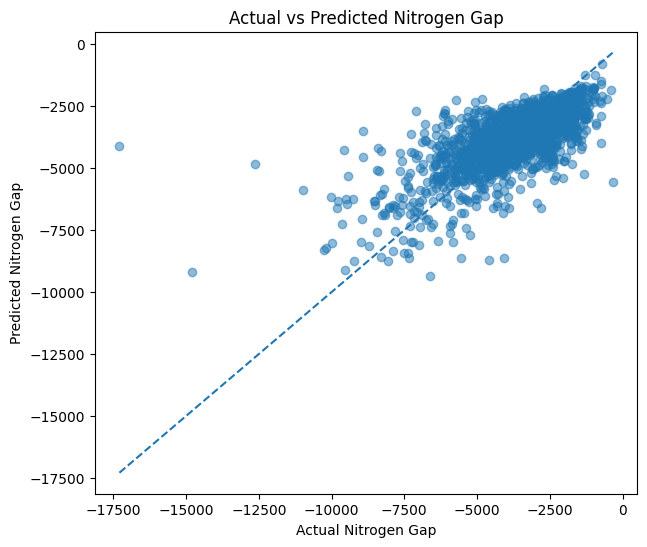

In [25]:
import matplotlib.pyplot as plt

# Scatter plot: actual vs predicted
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test_n,
    y_pred_n,
    alpha=0.5
)

# Perfect prediction reference line
min_value = min(y_test_n.min(), y_pred_n.min())
max_value = max(y_test_n.max(), y_pred_n.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Nitrogen Gap")
plt.ylabel("Predicted Nitrogen Gap")
plt.title("Actual vs Predicted Nitrogen Gap")

plt.show()

In [26]:
# Calculate prediction errors
results_n = pd.DataFrame({
    "Actual_Gap": y_test_n.values,
    "Predicted_Gap": y_pred_n
})

results_n["Absolute_Error"] = (
    results_n["Actual_Gap"] - results_n["Predicted_Gap"]
).abs()

# Divide actual gaps into ranges
results_n["Gap_Range"] = pd.cut(
    results_n["Actual_Gap"],
    bins=[-np.inf, -10000, -7500, -5000, -2500, 0, np.inf],
    labels=[
        "< -10000",
        "-10000 to -7500",
        "-7500 to -5000",
        "-5000 to -2500",
        "-2500 to 0",
        "> 0"
    ]
)

error_by_range = (
    results_n
    .groupby("Gap_Range", observed=False)["Absolute_Error"]
    .agg(["count", "mean"])
    .round(2)
)

display(error_by_range)

,count,mean
Gap_Range,,
< -10000,7,5637.48
-10000 to -7500,49,2062.34
-7500 to -5000,282,1234.88
-5000 to -2500,912,632.11
-2500 to 0,299,1107.40
> 0,0,NaN


In [27]:
# Check number of unique sites
print("Total unique sites:", train_df["site"].nunique())

# Number of samples per site
site_counts = train_df["site"].value_counts()

print("\nSite sample statistics:")
print(site_counts.describe())

print("\nSites with more than one sample:")
print((site_counts > 1).sum())

print("\nTop 10 sites by number of samples:")
display(site_counts.head(10))

Total unique sites: 819

Site sample statistics:
count    819.000000
mean       9.455433
std        8.376320
min        1.000000
25%        3.000000
50%        7.000000
75%       13.000000
max       44.000000
Name: count, dtype: float64

Sites with more than one sample:
713

Top 10 sites by number of samples:


,count
site,
site_id_2OfaUD,44
site_id_HD2z2x,42
site_id_dtmoGG,42
site_id_SFcTx8,42
site_id_EE3ExO,38
site_id_7urLh0,38
site_id_fHKoVt,37
site_id_OStEJl,37
site_id_eaSdY8,36


In [28]:
from sklearn.model_selection import GroupShuffleSplit

# Use the site information corresponding to the Nitrogen dataset
n_data_with_site = train_df[["PID", "site"] + core_features].merge(
    n_gap[["PID", "Gap"]],
    on="PID",
    how="inner"
)

# Features and target
X_n_site = n_data_with_site[core_features]
y_n_site = n_data_with_site["Gap"]
groups_n = n_data_with_site["site"]

# Split by site
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X_n_site, y_n_site, groups=groups_n)
)

X_train_site = X_n_site.iloc[train_idx]
X_test_site = X_n_site.iloc[test_idx]

y_train_site = y_n_site.iloc[train_idx]
y_test_site = y_n_site.iloc[test_idx]

train_sites = groups_n.iloc[train_idx]
test_sites = groups_n.iloc[test_idx]

print("Training samples:", X_train_site.shape)
print("Testing samples:", X_test_site.shape)

print("\nTraining sites:", train_sites.nunique())
print("Testing sites:", test_sites.nunique())

print("\nSites appearing in both sets:",
      len(set(train_sites) & set(test_sites)))

Training samples: (6195, 28)
Testing samples: (1549, 28)

Training sites: 655
Testing sites: 164

Sites appearing in both sets: 0


In [29]:
# XGBoost model using site-based train/test split

xgb_n_site = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_n_site.fit(X_train_site, y_train_site)

# Predict
y_pred_n_site = xgb_n_site.predict(X_test_site)

# Evaluate
mae_n_site = mean_absolute_error(y_test_site, y_pred_n_site)
rmse_n_site = np.sqrt(mean_squared_error(y_test_site, y_pred_n_site))
r2_n_site = r2_score(y_test_site, y_pred_n_site)

print("Site-Based XGBoost Nitrogen Gap Results")
print("-----------------------------------------")
print(f"MAE  : {mae_n_site:.2f}")
print(f"RMSE : {rmse_n_site:.2f}")
print(f"R²   : {r2_n_site:.4f}")

Site-Based XGBoost Nitrogen Gap Results
-----------------------------------------
MAE  : 942.57
RMSE : 1315.36
R²   : 0.4323


In [30]:
# Feature importance from the final site-based model

importance_site_df = pd.DataFrame({
    "Feature": X_train_site.columns,
    "Importance": xgb_n_site.feature_importances_
})

importance_site_df = importance_site_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print("Final Site-Based XGBoost Feature Importance:")
display(importance_site_df)

Final Site-Based XGBoost Feature Importance:


,Feature,Importance
0,ph20,0.105210
1,pH,0.083779
2,mb2,0.079596
3,mdem,0.056468
4,soc20,0.048294
5,lstd,0.046712
6,bio7,0.044852
7,lstn,0.037849
8,bio15,0.034632
9,xhp20,0.032051


In [31]:
import joblib
import os

# Create model directory
os.makedirs("soil_gap_models", exist_ok=True)

# Save XGBoost model
joblib.dump(
    xgb_n_site,
    "soil_gap_models/xgb_nitrogen_gap.pkl"
)

# Save imputer
joblib.dump(
    imputer,
    "soil_gap_models/soil_feature_imputer.pkl"
)

# Save feature list
joblib.dump(
    core_features,
    "soil_gap_models/nitrogen_gap_features.pkl"
)

print("Files saved successfully:")
print("1. xgb_nitrogen_gap.pkl")
print("2. soil_feature_imputer.pkl")
print("3. nitrogen_gap_features.pkl")

Files saved successfully:
1. xgb_nitrogen_gap.pkl
2. soil_feature_imputer.pkl
3. nitrogen_gap_features.pkl


In [32]:
# Select Phosphorus gap records
p_gap = gap_train_df[gap_train_df["Nutrient"] == "P"].copy()

# Match P-gap targets with soil/environment features
p_data = train_df[["PID", "site"] + core_features].merge(
    p_gap[["PID", "Gap"]],
    on="PID",
    how="inner"
)

print("Dataset shape:", p_data.shape)

print("\nTarget: Phosphorus Gap")

print("\nTarget statistics:")
print(p_data["Gap"].describe().round(2))

Dataset shape: (7744, 31)

Target: Phosphorus Gap

Target statistics:
count    7744.00
mean        0.40
std       106.98
min     -2183.72
25%         9.76
50%        27.70
75%        34.32
max        39.77
Name: Gap, dtype: float64


In [33]:
from sklearn.model_selection import GroupShuffleSplit

# Features and target
X_p = p_data[core_features]
y_p = p_data["Gap"]
groups_p = p_data["site"]

# Site-based split
gss_p = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_p, test_idx_p = next(
    gss_p.split(X_p, y_p, groups=groups_p)
)

X_train_p = X_p.iloc[train_idx_p]
X_test_p = X_p.iloc[test_idx_p]

y_train_p = y_p.iloc[train_idx_p]
y_test_p = y_p.iloc[test_idx_p]

train_sites_p = groups_p.iloc[train_idx_p]
test_sites_p = groups_p.iloc[test_idx_p]

print("Training samples:", X_train_p.shape)
print("Testing samples:", X_test_p.shape)

print("\nTraining sites:", train_sites_p.nunique())
print("Testing sites:", test_sites_p.nunique())

print(
    "\nSites appearing in both sets:",
    len(set(train_sites_p) & set(test_sites_p))
)

Training samples: (6195, 28)
Testing samples: (1549, 28)

Training sites: 655
Testing sites: 164

Sites appearing in both sets: 0


In [39]:
from xgboost import XGBRegressor

# XGBoost regression model for Phosphorus Gap
xgb_p_site = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_p_site.fit(X_train_p, y_train_p)

# Predict
y_pred_p_site = xgb_p_site.predict(X_test_p)

# Evaluate the trained Phosphorus Gap model

mae_p_site = mean_absolute_error(y_test_p, y_pred_p_site)
rmse_p_site = np.sqrt(mean_squared_error(y_test_p, y_pred_p_site))
r2_p_site = r2_score(y_test_p, y_pred_p_site)

print("Site-Based XGBoost Phosphorus Gap Results")
print("-------------------------------------------")
print(f"MAE  : {mae_p_site:.2f}")
print(f"RMSE : {rmse_p_site:.2f}")
print(f"R²   : {r2_p_site:.4f}")

Site-Based XGBoost Phosphorus Gap Results
-------------------------------------------
MAE  : 43.89
RMSE : 99.75
R²   : 0.0705


In [40]:
# Feature importance for Site-Based Phosphorus Gap Model

p_feature_importance = pd.Series(
    xgb_p_site.feature_importances_,
    index=core_features
).sort_values(ascending=False)

print("Top 15 Features for Phosphorus Gap Prediction")
print("-----------------------------------------------")
print(p_feature_importance.head(15))

Top 15 Features for Phosphorus Gap Prediction
-----------------------------------------------
ph20      0.067023
slope     0.046546
hp20      0.046305
bio15     0.043008
ecec20    0.042698
bio7      0.042312
lstn      0.038692
soc20     0.038454
bio1      0.038118
mdem      0.038081
tim       0.036218
bio12     0.035798
lstd      0.035390
wp        0.035357
mb3       0.034707
dtype: float32


In [41]:
# Prepare Potassium (K) Gap Dataset

k_gap = gap_train_df[gap_train_df["Nutrient"] == "K"].copy()

k_data = train_df[["PID", "site"] + core_features].merge(
    k_gap[["PID", "Gap"]],
    on="PID",
    how="inner"
)

print("Potassium Gap Dataset")
print("---------------------")
print("Shape:", k_data.shape)
print("Missing values:", k_data.isnull().sum().sum())
print("\nK Gap Statistics:")
print(k_data["Gap"].describe())

Potassium Gap Dataset
---------------------
Shape: (7744, 31)
Missing values: 19

K Gap Statistics:
count    7744.000000
mean     -964.612058
std       683.433075
min     -9092.800000
25%     -1283.845000
50%      -808.600000
75%      -479.180000
max        11.400000
Name: Gap, dtype: float64


In [42]:
from sklearn.model_selection import GroupShuffleSplit

X_k = k_data[core_features]
y_k = k_data["Gap"]
groups_k = k_data["site"]

group_split_k = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx_k, test_idx_k = next(
    group_split_k.split(X_k, y_k, groups=groups_k)
)

X_train_k = X_k.iloc[train_idx_k]
X_test_k = X_k.iloc[test_idx_k]
y_train_k = y_k.iloc[train_idx_k]
y_test_k = y_k.iloc[test_idx_k]

print("K Site-Based Split")
print("------------------")
print("Training samples:", X_train_k.shape)
print("Testing samples :", X_test_k.shape)
print("Training sites  :", groups_k.iloc[train_idx_k].nunique())
print("Testing sites   :", groups_k.iloc[test_idx_k].nunique())
print(
    "Shared sites    :",
    len(
        set(groups_k.iloc[train_idx_k])
        .intersection(set(groups_k.iloc[test_idx_k]))
    )
)

K Site-Based Split
------------------
Training samples: (6195, 28)
Testing samples : (1549, 28)
Training sites  : 655
Testing sites   : 164
Shared sites    : 0


In [43]:
from xgboost import XGBRegressor

xgb_k_site = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_k_site.fit(X_train_k, y_train_k)

y_pred_k_site = xgb_k_site.predict(X_test_k)

print("K-gap XGBoost model trained successfully.")

K-gap XGBoost model trained successfully.


In [44]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_k_site = mean_absolute_error(y_test_k, y_pred_k_site)
rmse_k_site = np.sqrt(mean_squared_error(y_test_k, y_pred_k_site))
r2_k_site = r2_score(y_test_k, y_pred_k_site)

print("Site-Based XGBoost Potassium Gap Results")
print("------------------------------------------")
print(f"MAE  : {mae_k_site:.2f}")
print(f"RMSE : {rmse_k_site:.2f}")
print(f"R²   : {r2_k_site:.4f}")

Site-Based XGBoost Potassium Gap Results
------------------------------------------
MAE  : 323.09
RMSE : 465.43
R²   : 0.5023


In [45]:
# Feature importance for Site-Based Potassium Gap Model

k_feature_importance = pd.Series(
    xgb_k_site.feature_importances_,
    index=core_features
).sort_values(ascending=False)

print("Top 15 Features for Potassium Gap Prediction")
print("----------------------------------------------")
print(k_feature_importance.head(15))

Top 15 Features for Potassium Gap Prediction
----------------------------------------------
bio7           0.171138
pH             0.068544
lstd           0.066364
bio12          0.052512
mdem           0.050073
xhp20          0.049403
BulkDensity    0.039392
bio15          0.038659
snd20          0.030681
bio1           0.028880
parv           0.028479
soc20          0.028455
slope          0.027316
mb7            0.026032
ph20           0.025876
dtype: float32


In [46]:
import os
import joblib

os.makedirs("soil_gap_models", exist_ok=True)

joblib.dump(
    xgb_k_site,
    "soil_gap_models/xgb_potassium_gap.pkl"
)

joblib.dump(
    core_features,
    "soil_gap_models/potassium_gap_features.pkl"
)

print("K-gap model saved successfully.")
print("Files:")
print("- soil_gap_models/xgb_potassium_gap.pkl")
print("- soil_gap_models/potassium_gap_features.pkl")

K-gap model saved successfully.
Files:
- soil_gap_models/xgb_potassium_gap.pkl
- soil_gap_models/potassium_gap_features.pkl


In [47]:
import os
import joblib

print("Saved Soil Gap Models")
print("---------------------")

model_files = [
    "xgb_nitrogen_gap.pkl",
    "xgb_potassium_gap.pkl"
]

for file in model_files:
    path = os.path.join("soil_gap_models", file)
    print(file, "->", "Found" if os.path.exists(path) else "Missing")

print("\nLoading saved models...")

n_model = joblib.load("soil_gap_models/xgb_nitrogen_gap.pkl")
k_model = joblib.load("soil_gap_models/xgb_potassium_gap.pkl")

print("N model loaded:", type(n_model).__name__)
print("K model loaded:", type(k_model).__name__)

print("\nAll saved models loaded successfully.")

Saved Soil Gap Models
---------------------
xgb_nitrogen_gap.pkl -> Found
xgb_potassium_gap.pkl -> Found

Loading saved models...
N model loaded: XGBRegressor
K model loaded: XGBRegressor

All saved models loaded successfully.


In [48]:
import joblib
import os

os.makedirs("soil_gap_models", exist_ok=True)

joblib.dump(
    xgb_p_site,
    "soil_gap_models/xgb_phosphorus_gap.pkl"
)

joblib.dump(
    core_features,
    "soil_gap_models/phosphorus_gap_features.pkl"
)

print("P-gap model saved successfully.")
print("Files:")
print("- soil_gap_models/xgb_phosphorus_gap.pkl")
print("- soil_gap_models/phosphorus_gap_features.pkl")

P-gap model saved successfully.
Files:
- soil_gap_models/xgb_phosphorus_gap.pkl
- soil_gap_models/phosphorus_gap_features.pkl


In [49]:
import joblib
import os

model_paths = {
    "Nitrogen (N)": "soil_gap_models/xgb_nitrogen_gap.pkl",
    "Phosphorus (P)": "soil_gap_models/xgb_phosphorus_gap.pkl",
    "Potassium (K)": "soil_gap_models/xgb_potassium_gap.pkl"
}

print("NPK Soil Gap Models")
print("-------------------")

loaded_models = {}

for nutrient, path in model_paths.items():
    if os.path.exists(path):
        loaded_models[nutrient] = joblib.load(path)
        print(f"{nutrient}: Loaded successfully")
    else:
        print(f"{nutrient}: Missing")

print("\nTotal models loaded:", len(loaded_models))

NPK Soil Gap Models
-------------------
Nitrogen (N): Loaded successfully
Phosphorus (P): Loaded successfully
Potassium (K): Loaded successfully

Total models loaded: 3


In [50]:
# Generate NPK gap predictions

n_pred = n_model.predict(X_test_n)
p_pred = xgb_p_site.predict(X_test_p)
k_pred = k_model.predict(X_test_k)

print("NPK predictions generated successfully.")
print("N predictions:", len(n_pred))
print("P predictions:", len(p_pred))
print("K predictions:", len(k_pred))

NPK predictions generated successfully.
N predictions: 1549
P predictions: 1549
K predictions: 1549


In [51]:
# Create NPK prediction summary

npk_results = pd.DataFrame({
    "Actual_N_Gap": y_test_n.reset_index(drop=True),
    "Predicted_N_Gap": n_pred,
    "Actual_P_Gap": y_test_p.reset_index(drop=True),
    "Predicted_P_Gap": p_pred,
    "Actual_K_Gap": y_test_k.reset_index(drop=True),
    "Predicted_K_Gap": k_pred
})

print("NPK Prediction Summary")
print("----------------------")
print("Shape:", npk_results.shape)

display(npk_results.head(10))

NPK Prediction Summary
----------------------
Shape: (1549, 6)


,Actual_N_Gap,Predicted_N_Gap,Actual_P_Gap,Predicted_P_Gap,Actual_K_Gap,Predicted_K_Gap
0,-8420.4,-6860.981445,27.5608,37.391571,-108.60,-388.011658
1,-4364.0,-4083.942627,2.6080,-30.329433,-127.36,-223.746475
2,-5700.0,-5606.655762,-39.4260,-312.867188,-99.00,-142.164658
3,-3169.6,-2892.411621,-14.3400,-52.344734,-125.32,-416.793030
4,-4220.0,-3587.249512,32.3352,-0.755666,-73.96,-399.708740
5,-3436.0,-4105.500488,23.3338,-2.203111,-421.76,-368.675690
6,-2366.0,-1902.868042,38.6280,17.969332,-300.80,-448.643524
7,-6092.0,-5536.001953,24.8884,-17.720598,-65.60,-878.431213
8,-2804.0,-2567.656494,34.0300,22.922836,-203.00,-485.532043
9,-2193.2,-2433.805664,39.7060,15.190317,-268.46,-627.685364


In [52]:
# Summary of predicted NPK gaps

print("Predicted NPK Gap Statistics")
print("----------------------------")

print("\nNitrogen (N):")
print(pd.Series(n_pred).describe())

print("\nPhosphorus (P):")
print(pd.Series(p_pred).describe())

print("\nPotassium (K):")
print(pd.Series(k_pred).describe())

Predicted NPK Gap Statistics
----------------------------

Nitrogen (N):
count     1549.000000
mean     -3895.555908
std       1338.562622
min     -14126.731445
25%      -4586.873535
50%      -3736.162109
75%      -2975.339600
max       -817.596008
dtype: float64

Phosphorus (P):
count    1549.000000
mean       -8.874560
std        56.124512
min      -447.491577
25%       -21.380959
50%         8.321291
75%        26.916248
max        48.630154
dtype: float64

Potassium (K):
count    1549.000000
mean     -982.236938
std       466.194122
min     -3172.284668
25%     -1234.471680
50%      -853.134216
75%      -655.718079
max      -142.164658
dtype: float64


In [53]:
# Create NPK nutrient status from predicted gaps

npk_assessment = npk_results.copy()

npk_assessment["N_Status"] = np.where(
    npk_assessment["Predicted_N_Gap"] > 0,
    "Gap Present",
    "No Positive Gap"
)

npk_assessment["P_Status"] = np.where(
    npk_assessment["Predicted_P_Gap"] > 0,
    "Gap Present",
    "No Positive Gap"
)

npk_assessment["K_Status"] = np.where(
    npk_assessment["Predicted_K_Gap"] > 0,
    "Gap Present",
    "No Positive Gap"
)

print("NPK Nutrient Status")
print("-------------------")

display(
    npk_assessment[
        [
            "Predicted_N_Gap",
            "N_Status",
            "Predicted_P_Gap",
            "P_Status",
            "Predicted_K_Gap",
            "K_Status"
        ]
    ].head(10)
)

NPK Nutrient Status
-------------------


,Predicted_N_Gap,N_Status,Predicted_P_Gap,P_Status,Predicted_K_Gap,K_Status
0,-6860.981445,No Positive Gap,37.391571,Gap Present,-388.011658,No Positive Gap
1,-4083.942627,No Positive Gap,-30.329433,No Positive Gap,-223.746475,No Positive Gap
2,-5606.655762,No Positive Gap,-312.867188,No Positive Gap,-142.164658,No Positive Gap
3,-2892.411621,No Positive Gap,-52.344734,No Positive Gap,-416.793030,No Positive Gap
4,-3587.249512,No Positive Gap,-0.755666,No Positive Gap,-399.708740,No Positive Gap
5,-4105.500488,No Positive Gap,-2.203111,No Positive Gap,-368.675690,No Positive Gap
6,-1902.868042,No Positive Gap,17.969332,Gap Present,-448.643524,No Positive Gap
7,-5536.001953,No Positive Gap,-17.720598,No Positive Gap,-878.431213,No Positive Gap
8,-2567.656494,No Positive Gap,22.922836,Gap Present,-485.532043,No Positive Gap
9,-2433.805664,No Positive Gap,15.190317,Gap Present,-627.685364,No Positive Gap


In [54]:
# Count predicted positive nutrient gaps

n_gap_count = (npk_assessment["Predicted_N_Gap"] > 0).sum()
p_gap_count = (npk_assessment["Predicted_P_Gap"] > 0).sum()
k_gap_count = (npk_assessment["Predicted_K_Gap"] > 0).sum()

total_samples = len(npk_assessment)

print("Predicted Positive NPK Gaps")
print("---------------------------")

print(f"Nitrogen (N):  {n_gap_count} / {total_samples} "
      f"({n_gap_count / total_samples * 100:.2f}%)")

print(f"Phosphorus (P): {p_gap_count} / {total_samples} "
      f"({p_gap_count / total_samples * 100:.2f}%)")

print(f"Potassium (K): {k_gap_count} / {total_samples} "
      f"({k_gap_count / total_samples * 100:.2f}%)")

Predicted Positive NPK Gaps
---------------------------
Nitrogen (N):  0 / 1549 (0.00%)
Phosphorus (P): 903 / 1549 (58.30%)
Potassium (K): 0 / 1549 (0.00%)


In [55]:
# Compare actual and predicted average gaps

comparison = pd.DataFrame({
    "N": [
        y_test_n.mean(),
        np.mean(n_pred)
    ],
    "P": [
        y_test_p.mean(),
        np.mean(p_pred)
    ],
    "K": [
        y_test_k.mean(),
        np.mean(k_pred)
    ]
}, index=["Actual Mean Gap", "Predicted Mean Gap"])

print("Actual vs Predicted Mean NPK Gaps")
print("---------------------------------")

display(comparison)

Actual vs Predicted Mean NPK Gaps
---------------------------------


,N,P,K
Actual Mean Gap,-3898.743189,-2.419508,-985.061059
Predicted Mean Gap,-3895.555908,-8.874560,-982.236938


In [56]:
# Compare actual and predicted positive-gap counts

for nutrient, actual, predicted in [
    ("N", y_test_n, n_pred),
    ("P", y_test_p, p_pred),
    ("K", y_test_k, k_pred)
]:
    actual_positive = (actual.reset_index(drop=True) > 0).sum()
    predicted_positive = (predicted > 0).sum()

    print(f"{nutrient} - Actual positive gaps    : "
          f"{actual_positive} / {len(actual)} "
          f"({actual_positive / len(actual) * 100:.2f}%)")

    print(f"{nutrient} - Predicted positive gaps : "
          f"{predicted_positive} / {len(predicted)} "
          f"({predicted_positive / len(predicted) * 100:.2f}%)")

    print()

N - Actual positive gaps    : 0 / 1549 (0.00%)
N - Predicted positive gaps : 0 / 1549 (0.00%)

P - Actual positive gaps    : 1230 / 1549 (79.41%)
P - Predicted positive gaps : 903 / 1549 (58.30%)

K - Actual positive gaps    : 0 / 1549 (0.00%)
K - Predicted positive gaps : 0 / 1549 (0.00%)



In [57]:
from sklearn.metrics import classification_report, confusion_matrix

# Convert actual and predicted P gaps into binary gap-status labels
p_actual_status = (y_test_p.reset_index(drop=True) > 0).astype(int)
p_pred_status = (p_pred > 0).astype(int)

print("Phosphorus Positive-Gap Classification")
print("---------------------------------------")

print(classification_report(
    p_actual_status,
    p_pred_status,
    target_names=["No Positive Gap", "Gap Present"],
    digits=4
))

print("Confusion Matrix:")
print(confusion_matrix(p_actual_status, p_pred_status))

Phosphorus Positive-Gap Classification
---------------------------------------
                 precision    recall  f1-score   support

No Positive Gap     0.3854    0.7806    0.5161       319
    Gap Present     0.9225    0.6772    0.7811      1230

       accuracy                         0.6985      1549
      macro avg     0.6540    0.7289    0.6486      1549
   weighted avg     0.8119    0.6985    0.7265      1549

Confusion Matrix:
[[249  70]
 [397 833]]


In [58]:
# Save the NPK prediction and assessment results

npk_assessment.to_csv(
    "soil_gap_models/npk_gap_assessment.csv",
    index=False
)

print("NPK assessment saved successfully.")
print("File: soil_gap_models/npk_gap_assessment.csv")
print("Rows:", len(npk_assessment))
print("Columns:", len(npk_assessment.columns))

NPK assessment saved successfully.
File: soil_gap_models/npk_gap_assessment.csv
Rows: 1549
Columns: 9


In [59]:
from google.colab import drive
import shutil
import os

drive.mount("/content/drive")

source_folder = "soil_gap_models"
drive_folder = "/content/drive/MyDrive/AI_Soil_Analytics/soil_gap_models"

os.makedirs(
    "/content/drive/MyDrive/AI_Soil_Analytics",
    exist_ok=True
)

if os.path.exists(drive_folder):
    shutil.rmtree(drive_folder)

shutil.copytree(source_folder, drive_folder)

print("Soil gap models backed up successfully.")
print("Google Drive location:")
print(drive_folder)

print("\nBacked-up files:")
for file in os.listdir(drive_folder):
    print("-", file)

Mounted at /content/drive
Soil gap models backed up successfully.
Google Drive location:
/content/drive/MyDrive/AI_Soil_Analytics/soil_gap_models

Backed-up files:
- xgb_phosphorus_gap.pkl
- nitrogen_gap_features.pkl
- xgb_potassium_gap.pkl
- xgb_nitrogen_gap.pkl
- phosphorus_gap_features.pkl
- npk_gap_assessment.csv
- potassium_gap_features.pkl
- soil_feature_imputer.pkl


In [60]:
# Install and import SHAP

!pip install -q shap

import shap
import matplotlib.pyplot as plt

print("SHAP version:", shap.__version__)
print("SHAP imported successfully.")

SHAP version: 0.52.0
SHAP imported successfully.


In [61]:
# Create SHAP explainer for the K-gap XGBoost model

k_explainer = shap.TreeExplainer(k_model)

print("SHAP explainer created successfully.")

SHAP explainer created successfully.


In [62]:
# Calculate SHAP values for the K-gap model

k_shap_values = k_explainer.shap_values(X_test_k)

print("SHAP values calculated successfully.")
print("SHAP values shape:", k_shap_values.shape)
print("Test data shape:", X_test_k.shape)

SHAP values calculated successfully.
SHAP values shape: (1549, 28)
Test data shape: (1549, 28)


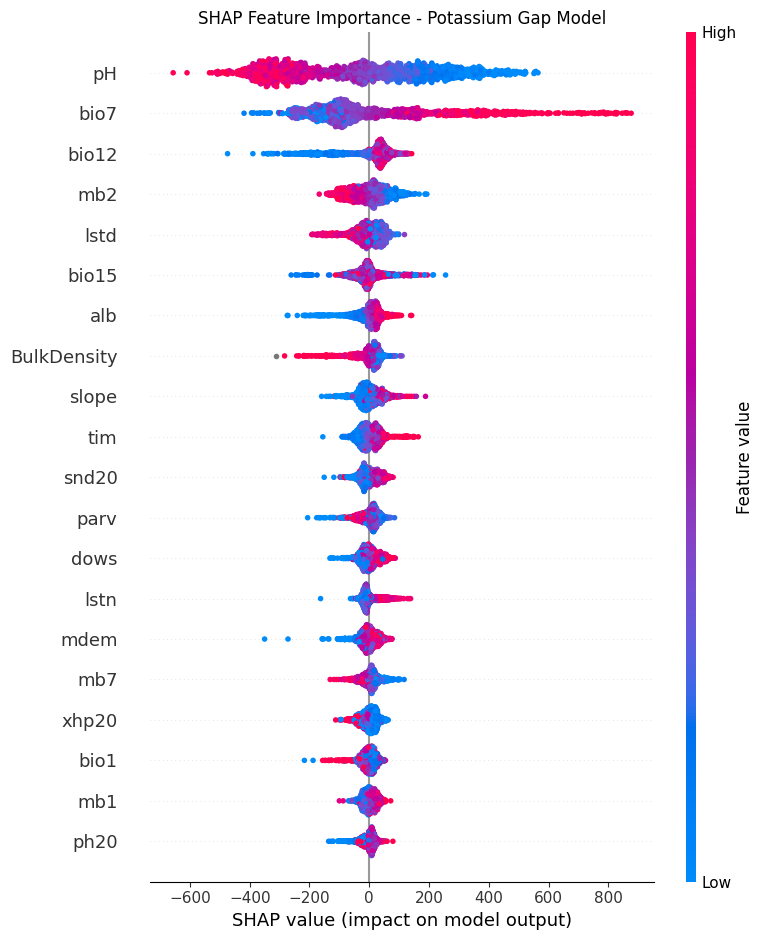

In [63]:
# SHAP Feature Importance Summary Plot

plt.figure(figsize=(10, 8))

shap.summary_plot(
    k_shap_values,
    X_test_k,
    show=False
)

plt.title("SHAP Feature Importance - Potassium Gap Model")
plt.tight_layout()
plt.show()

In [64]:
# Calculate mean absolute SHAP importance

shap_importance = pd.DataFrame({
    "Feature": X_test_k.columns,
    "Mean_Absolute_SHAP": np.abs(k_shap_values).mean(axis=0)
})

shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

print("Top 15 SHAP Features - Potassium Gap Model")
print("--------------------------------------------")

display(shap_importance.head(15))

Top 15 SHAP Features - Potassium Gap Model
--------------------------------------------


,Feature,Mean_Absolute_SHAP
0,pH,219.594833
1,bio7,185.885696
2,bio12,66.396355
3,mb2,48.669464
4,lstd,36.047485
5,bio15,34.815159
6,alb,30.633554
7,BulkDensity,29.902628
8,slope,27.615606
9,tim,26.210690


In [65]:
# Save SHAP feature importance results

shap_importance.to_csv(
    "soil_gap_models/k_shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved successfully.")
print("File: soil_gap_models/k_shap_feature_importance.csv")

SHAP feature importance saved successfully.
File: soil_gap_models/k_shap_feature_importance.csv


In [66]:
import torch
import torch.nn as nn
from torchvision import models

# Load ResNet-50 architecture
hybrid_cnn_model = models.resnet50(weights=None)

# 4 soil classes
num_classes = 4

hybrid_cnn_model.fc = nn.Linear(
    hybrid_cnn_model.fc.in_features,
    num_classes
)

# Load the fine-tuned model
cnn_model_path = "/content/drive/MyDrive/AI_Soil_Analytics/models/resnet50_finetuned_final.pth"

hybrid_cnn_model.load_state_dict(
    torch.load(cnn_model_path, map_location="cpu")
)

hybrid_cnn_model.eval()

print("ResNet-50 model loaded successfully.")
print("Model path:", cnn_model_path)

ResNet-50 model loaded successfully.
Model path: /content/drive/MyDrive/AI_Soil_Analytics/models/resnet50_finetuned_final.pth


In [67]:
# Define soil class labels used by the CNN

soil_classes = [
    "Alluvial soil",
    "Black Soil",
    "Clay soil",
    "Red soil"
]

print("CNN Soil Classes")
print("-----------------")

for i, class_name in enumerate(soil_classes):
    print(f"{i}: {class_name}")

CNN Soil Classes
-----------------
0: Alluvial soil
1: Black Soil
2: Clay soil
3: Red soil


In [68]:
from torchvision import transforms

# Image preprocessing for ResNet-50
hybrid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("CNN image preprocessing configured successfully.")
print("Input image size: 224 x 224")

CNN image preprocessing configured successfully.
Input image size: 224 x 224


In [69]:
from PIL import Image
import torch
import torch.nn.functional as F

def predict_soil_type(image_path):
    # Load image
    image = Image.open(image_path).convert("RGB")

    # Apply preprocessing
    image_tensor = hybrid_transform(image).unsqueeze(0)

    # Make prediction
    with torch.no_grad():
        outputs = hybrid_cnn_model(image_tensor)
        probabilities = F.softmax(outputs, dim=1)

    # Get predicted class and confidence
    confidence, predicted_index = torch.max(probabilities, dim=1)

    predicted_class = soil_classes[predicted_index.item()]
    confidence_value = confidence.item()

    # All class probabilities
    class_probabilities = {
        soil_classes[i]: probabilities[0][i].item()
        for i in range(len(soil_classes))
    }

    return predicted_class, confidence_value, class_probabilities


print("CNN prediction function created successfully.")

CNN prediction function created successfully.


In [70]:
from google.colab import files

uploaded = files.upload()

test_image_path = next(iter(uploaded))

print("Image uploaded successfully.")
print("Test image:", test_image_path)

KeyboardInterrupt: 

In [72]:
import os

search_folders = [
    "/content/soil_dataset",
    "/content/soil_data",
    "/content/soil_images",
    "/content/dataset"
]

print("Checking for soil image folders...\n")

for folder in search_folders:
    if os.path.exists(folder):
        print("FOUND:", folder)
        for root, dirs, files in os.walk(folder):
            image_files = [
                f for f in files
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ]
            if image_files:
                print("  Image folder:", root)
                print("  Number of images:", len(image_files))
                print("  Example:", image_files[:3])

Checking for soil image folders...



In [73]:
import os

drive_root = "/content/drive/MyDrive/AI_Soil_Analytics"

print("Checking AI_Soil_Analytics folder...\n")

for root, dirs, files in os.walk(drive_root):
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if image_files:
        print("Image folder found:", root)
        print("Number of images:", len(image_files))
        print("Examples:", image_files[:5])

Checking AI_Soil_Analytics folder...



In [74]:
# Download the original soil image dataset

!wget -q -O soil_images.zip \
"https://www.kaggle.com/api/v1/datasets/download/jayaprakashpondy/soil-image-dataset"

print("Dataset downloaded successfully.")

Dataset downloaded successfully.


In [75]:
import zipfile
import os

zip_path = "soil_images.zip"
extract_path = "/content/soil_image_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully.")
print("Location:", extract_path)

print("\nFiles/folders:")
for item in os.listdir(extract_path):
    print("-", item)

Dataset extracted successfully.
Location: /content/soil_image_dataset

Files/folders:
- Dataset


In [76]:
import os

dataset_path = "/content/soil_image_dataset/Dataset"

print("Soil Dataset Contents")
print("---------------------")

for item in os.listdir(dataset_path):
    full_path = os.path.join(dataset_path, item)

    if os.path.isdir(full_path):
        image_count = sum(
            1 for f in os.listdir(full_path)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        )
        print(f"{item} -> {image_count} images")
    else:
        print(item)

Soil Dataset Contents
---------------------
Train -> 0 images
test -> 0 images


In [77]:
import os

dataset_path = "/content/soil_image_dataset/Dataset"

for root, dirs, files in os.walk(dataset_path):
    image_files = [
        f for f in files
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    if image_files:
        print("Folder:", root)
        print("Images:", len(image_files))
        print("Examples:", image_files[:3])
        print()

Folder: /content/soil_image_dataset/Dataset/Train/Red soil
Images: 262
Examples: ['Red_29.jpg', 'brown-soil.jpg', 'Copy of image24.jpeg']

Folder: /content/soil_image_dataset/Dataset/Train/Clay soil
Images: 199
Examples: ['Sample3.90.jpg', 'Sample1.90.jpg', 'Copy of images22.jpg']

Folder: /content/soil_image_dataset/Dataset/Train/Black Soil
Images: 228
Examples: ['Copy of images350.jpg', 'Copy of images406(1).jpg', 'Copy of images363.jpg']

Folder: /content/soil_image_dataset/Dataset/Train/Alluvial soil
Images: 525
Examples: ['Copy of IMG-20220531-WA0088.jpg', 'images96.jpg', 'Copy of IMG-20220531-WA0045.jpg']

Folder: /content/soil_image_dataset/Dataset/test/Red soil
Images: 105
Examples: ['Red_29.jpg', 'Copy of image24.jpeg', 'Copy of image17.jpeg']

Folder: /content/soil_image_dataset/Dataset/test/Clay soil
Images: 65
Examples: ['Clay_13.jpg', 'Copy of images43(1).jpg', 'Copy of clay-soil2.jpg']

Folder: /content/soil_image_dataset/Dataset/test/Black Soil
Images: 116
Examples: ['Co

In [78]:
import os

test_class_path = "/content/soil_image_dataset/Dataset/test/Alluvial soil"

image_files = [
    f for f in os.listdir(test_class_path)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

test_image_path = os.path.join(test_class_path, image_files[0])

print("Test image selected:")
print(test_image_path)

Test image selected:
/content/soil_image_dataset/Dataset/test/Alluvial soil/image7 (2).jpeg


In [79]:
# Test the saved ResNet-50 on the selected soil image

predicted_class, confidence, probabilities = predict_soil_type(
    test_image_path
)

print("CNN Soil Prediction")
print("--------------------")
print("Actual class   : Alluvial soil")
print("Predicted class:", predicted_class)
print(f"Confidence     : {confidence * 100:.2f}%")

print("\nClass Probabilities:")
for class_name, probability in probabilities.items():
    print(f"{class_name}: {probability * 100:.2f}%")

CNN Soil Prediction
--------------------
Actual class   : Alluvial soil
Predicted class: Alluvial soil
Confidence     : 95.51%

Class Probabilities:
Alluvial soil: 95.51%
Black Soil: 2.80%
Clay soil: 0.34%
Red soil: 1.35%


In [80]:
def hybrid_soil_assessment(image_path, structured_data):
    """
    Combine CNN soil-type prediction with NPK gap predictions.

    structured_data must contain the 28 features used by the NPK models.
    """

    # -------------------------
    # 1. CNN soil prediction
    # -------------------------
    soil_type, cnn_confidence, class_probabilities = predict_soil_type(
        image_path
    )

    # -------------------------
    # 2. Prepare structured data
    # -------------------------
    X_input = pd.DataFrame(
        [structured_data],
        columns=core_features
    )

    # -------------------------
    # 3. NPK gap predictions
    # -------------------------
    n_gap_prediction = n_model.predict(X_input)[0]
    p_gap_prediction = xgb_p_site.predict(X_input)[0]
    k_gap_prediction = k_model.predict(X_input)[0]

    # -------------------------
    # 4. Return combined result
    # -------------------------
    result = {
        "Soil Type": soil_type,
        "CNN Confidence": cnn_confidence,
        "Nitrogen Gap": n_gap_prediction,
        "Phosphorus Gap": p_gap_prediction,
        "Potassium Gap": k_gap_prediction,
        "Class Probabilities": class_probabilities
    }

    return result


print("Hybrid soil assessment function created successfully.")

Hybrid soil assessment function created successfully.


In [81]:
# Select one real soil sample from the structured dataset

sample_row = train_df.iloc[0]

sample_structured_data = {
    feature: sample_row[feature]
    for feature in core_features
}

print("Structured soil sample selected.")
print("\nSample values:")
display(pd.DataFrame([sample_structured_data]))

Structured soil sample selected.

Sample values:


,pH,alb,bio1,bio12,bio15,bio7,cec20,dows,ecec20,hp20,...,para,parv,ph20,slope,snd20,soc20,tim,wp,xhp20,BulkDensity
0,7.75,176,248,920,108,190,22.0,21.500278,11.00779,0.00779,...,20.544283,126.83548,7.05,1.962921,39.0,9.75,7.962668,0.016853,0.000708,1.46


In [82]:
# Run the complete hybrid soil assessment

hybrid_result = hybrid_soil_assessment(
    test_image_path,
    sample_structured_data
)

print("Hybrid Soil Assessment")
print("======================")

print(f"Soil Type       : {hybrid_result['Soil Type']}")
print(f"CNN Confidence  : {hybrid_result['CNN Confidence'] * 100:.2f}%")

print("\nPredicted Nutrient Gaps")
print("-----------------------")
print(f"Nitrogen (N)    : {hybrid_result['Nitrogen Gap']:.2f}")
print(f"Phosphorus (P)  : {hybrid_result['Phosphorus Gap']:.2f}")
print(f"Potassium (K)   : {hybrid_result['Potassium Gap']:.2f}")

print("\nClass Probabilities")
print("-------------------")
for soil_class, probability in hybrid_result["Class Probabilities"].items():
    print(f"{soil_class}: {probability * 100:.2f}%")

Hybrid Soil Assessment
Soil Type       : Alluvial soil
CNN Confidence  : 95.51%

Predicted Nutrient Gaps
-----------------------
Nitrogen (N)    : -3576.23
Phosphorus (P)  : 6.37
Potassium (K)   : -459.43

Class Probabilities
-------------------
Alluvial soil: 95.51%
Black Soil: 2.80%
Clay soil: 0.34%
Red soil: 1.35%


In [83]:
# Add nutrient status to the hybrid assessment

def get_gap_status(gap):
    if gap > 0:
        return "Positive Gap"
    else:
        return "No Positive Gap"


hybrid_result["N Status"] = get_gap_status(
    hybrid_result["Nitrogen Gap"]
)

hybrid_result["P Status"] = get_gap_status(
    hybrid_result["Phosphorus Gap"]
)

hybrid_result["K Status"] = get_gap_status(
    hybrid_result["Potassium Gap"]
)

print("Hybrid NPK Status")
print("=================")

print(f"Nitrogen   : {hybrid_result['N Status']}")
print(f"Phosphorus : {hybrid_result['P Status']}")
print(f"Potassium  : {hybrid_result['K Status']}")

Hybrid NPK Status
Nitrogen   : No Positive Gap
Phosphorus : Positive Gap
Potassium  : No Positive Gap


In [86]:
# Add NPK status to the hybrid result

hybrid_result["Nitrogen Status"] = get_gap_status(hybrid_result["Nitrogen Gap"])
hybrid_result["Phosphorus Status"] = get_gap_status(hybrid_result["Phosphorus Gap"])
hybrid_result["Potassium Status"] = get_gap_status(hybrid_result["Potassium Gap"])

print("Hybrid NPK Status")
print("=================")
print(f"Nitrogen   : {hybrid_result['Nitrogen Status']}")
print(f"Phosphorus : {hybrid_result['Phosphorus Status']}")
print(f"Potassium  : {hybrid_result['Potassium Status']}")

Hybrid NPK Status
Nitrogen   : No Positive Gap
Phosphorus : Positive Gap
Potassium  : No Positive Gap


In [87]:
# Calculate overall soil health score based on NPK gap status

npk_statuses = [
    hybrid_result["Nitrogen Status"],
    hybrid_result["Phosphorus Status"],
    hybrid_result["Potassium Status"]
]

positive_gaps = npk_statuses.count("Positive Gap")
total_nutrients = len(npk_statuses)

# Each nutrient without a positive gap contributes equally
soil_health_score = ((total_nutrients - positive_gaps) / total_nutrients) * 100

if soil_health_score >= 80:
    soil_health_category = "Good"
elif soil_health_score >= 60:
    soil_health_category = "Moderate"
else:
    soil_health_category = "Needs Improvement"

print("Soil Health Assessment")
print("======================")
print(f"Soil Health Score : {soil_health_score:.2f}/100")
print(f"Soil Health Level : {soil_health_category}")

Soil Health Assessment
Soil Health Score : 66.67/100
Soil Health Level : Moderate


In [88]:
# Classify CNN confidence level

cnn_confidence = hybrid_result["CNN Confidence"]

if cnn_confidence >= 0.80:
    confidence_level = "High"
elif cnn_confidence >= 0.60:
    confidence_level = "Medium"
else:
    confidence_level = "Low"

hybrid_result["Confidence Level"] = confidence_level

print("CNN Confidence Assessment")
print("=========================")
print(f"Confidence : {cnn_confidence:.2%}")
print(f"Level      : {confidence_level}")

CNN Confidence Assessment
Confidence : 95.51%
Level      : High


In [89]:
# Final Hybrid Soil Assessment Report

print("=" * 45)
print("       HYBRID SOIL ASSESSMENT REPORT")
print("=" * 45)

print(f"\nSoil Type           : {hybrid_result['Soil Type']}")
print(f"CNN Confidence     : {hybrid_result['CNN Confidence']:.2%}")
print(f"Confidence Level   : {hybrid_result['Confidence Level']}")

print("\nNUTRIENT GAP ASSESSMENT")
print("-" * 30)

print(f"Nitrogen (N)       : {hybrid_result['Nitrogen Gap']:.2f}")
print(f"Status             : {hybrid_result['Nitrogen Status']}")

print(f"\nPhosphorus (P)     : {hybrid_result['Phosphorus Gap']:.2f}")
print(f"Status             : {hybrid_result['Phosphorus Status']}")

print(f"\nPotassium (K)      : {hybrid_result['Potassium Gap']:.2f}")
print(f"Status             : {hybrid_result['Potassium Status']}")

print("\nSOIL HEALTH")
print("-" * 30)
print(f"Soil Health Score  : {soil_health_score:.2f}/100")
print(f"Overall Level      : {soil_health_category}")

print("\n" + "=" * 45)

       HYBRID SOIL ASSESSMENT REPORT

Soil Type           : Alluvial soil
CNN Confidence     : 95.51%
Confidence Level   : High

NUTRIENT GAP ASSESSMENT
------------------------------
Nitrogen (N)       : -3576.23
Status             : No Positive Gap

Phosphorus (P)     : 6.37
Status             : Positive Gap

Potassium (K)      : -459.43
Status             : No Positive Gap

SOIL HEALTH
------------------------------
Soil Health Score  : 66.67/100
Overall Level      : Moderate



In [95]:
import os
import glob

# Find one image automatically from each soil class

soil_test_base = "/content/soil_image_dataset/Dataset/test"

soil_classes_for_test = [
    "Alluvial soil",
    "Black Soil",
    "Clay soil",
    "Red soil"
]

test_images = []

for soil_class in soil_classes_for_test:
    class_folder = os.path.join(soil_test_base, soil_class)

    images = []
    for ext in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
        images.extend(glob.glob(os.path.join(class_folder, ext)))

    if len(images) > 0:
        test_images.append(images[0])
        print(f"{soil_class}: {os.path.basename(images[0])}")
    else:
        print(f"{soil_class}: No image found")

print("\nTotal test images selected:", len(test_images))

Alluvial soil: Alluvial_26.jpg
Black Soil: Copy of images350.jpg
Clay soil: Clay_13.jpg
Red soil: Red_29.jpg

Total test images selected: 4


In [98]:
import os

print("Checking selected images:")
print("========================")

for image_path in test_images:
    print(image_path, "->", os.path.exists(image_path))

Checking selected images:
/content/soil_image_dataset/Dataset/test/Alluvial soil/image7 (2).jpeg -> True
/content/soil_image_dataset/Dataset/test/Black Soil/image1.jpeg -> False
/content/soil_image_dataset/Dataset/test/Clay soil/image1.jpeg -> False
/content/soil_image_dataset/Dataset/test/Red soil/image1.jpeg -> False


In [99]:
import glob
import os

soil_test_base = "/content/soil_image_dataset/Dataset/test"

soil_classes_for_test = [
    "Alluvial soil",
    "Black Soil",
    "Clay soil",
    "Red soil"
]

test_images = []

for soil_class in soil_classes_for_test:
    folder = os.path.join(soil_test_base, soil_class)

    files = []
    for extension in ["*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"]:
        files.extend(glob.glob(os.path.join(folder, extension)))

    if files:
        test_images.append(files[0])
        print(f"{soil_class}: {files[0]}")

print("\nChecking paths:")
for path in test_images:
    print(os.path.exists(path), path)

Alluvial soil: /content/soil_image_dataset/Dataset/test/Alluvial soil/Alluvial_26.jpg
Black Soil: /content/soil_image_dataset/Dataset/test/Black Soil/Copy of images350.jpg
Clay soil: /content/soil_image_dataset/Dataset/test/Clay soil/Clay_13.jpg
Red soil: /content/soil_image_dataset/Dataset/test/Red soil/Red_29.jpg

Checking paths:
True /content/soil_image_dataset/Dataset/test/Alluvial soil/Alluvial_26.jpg
True /content/soil_image_dataset/Dataset/test/Black Soil/Copy of images350.jpg
True /content/soil_image_dataset/Dataset/test/Clay soil/Clay_13.jpg
True /content/soil_image_dataset/Dataset/test/Red soil/Red_29.jpg


In [100]:
# Test CNN prediction on all four soil images

print("CNN Soil Classification Test")
print("============================")

for image_path in test_images:
    soil_type, confidence, probabilities = predict_soil_type(image_path)

    print(f"\nImage     : {os.path.basename(image_path)}")
    print(f"Soil Type : {soil_type}")
    print(f"Confidence: {confidence:.2%}")

CNN Soil Classification Test

Image     : Alluvial_26.jpg
Soil Type : Alluvial soil
Confidence: 99.97%

Image     : Copy of images350.jpg
Soil Type : Black Soil
Confidence: 99.58%

Image     : Clay_13.jpg
Soil Type : Clay soil
Confidence: 99.95%

Image     : Red_29.jpg
Soil Type : Red soil
Confidence: 98.26%


In [101]:
# Test NPK gap predictions for four structured soil samples

npk_test_results = []

for i in range(4):

    structured_sample = train_df.iloc[i][core_features].to_dict()

    X_input = pd.DataFrame(
        [structured_sample],
        columns=core_features
    )

    n_gap = n_model.predict(X_input)[0]
    p_gap = xgb_p_site.predict(X_input)[0]
    k_gap = k_model.predict(X_input)[0]

    npk_test_results.append({
        "Sample": i + 1,
        "Nitrogen Gap": n_gap,
        "Phosphorus Gap": p_gap,
        "Potassium Gap": k_gap,
        "N Status": get_gap_status(n_gap),
        "P Status": get_gap_status(p_gap),
        "K Status": get_gap_status(k_gap)
    })

npk_test_df = pd.DataFrame(npk_test_results)

print("NPK Gap Prediction Test")
print("=======================")

display(npk_test_df)

NPK Gap Prediction Test


,Sample,Nitrogen Gap,Phosphorus Gap,Potassium Gap,N Status,P Status,K Status
0,1,-3576.228516,6.369735,-459.432190,No Positive Gap,Positive Gap,No Positive Gap
1,2,-4254.202637,-5.913857,-400.233704,No Positive Gap,No Positive Gap,No Positive Gap
2,3,-8731.016602,-39.955139,-323.564545,No Positive Gap,No Positive Gap,No Positive Gap
3,4,-5861.171875,-47.785183,-439.135590,No Positive Gap,No Positive Gap,No Positive Gap


In [102]:
# Final multi-sample Hybrid Soil Assessment

hybrid_test_results = []

for i, image_path in enumerate(test_images):

    # -----------------------------
    # 1. CNN soil classification
    # -----------------------------
    soil_type, confidence, probabilities = predict_soil_type(image_path)

    # -----------------------------
    # 2. Structured soil data
    # -----------------------------
    structured_sample = train_df.iloc[i][core_features].to_dict()

    X_input = pd.DataFrame(
        [structured_sample],
        columns=core_features
    )

    # -----------------------------
    # 3. NPK gap predictions
    # -----------------------------
    n_gap = n_model.predict(X_input)[0]
    p_gap = xgb_p_site.predict(X_input)[0]
    k_gap = k_model.predict(X_input)[0]

    # -----------------------------
    # 4. Nutrient status
    # -----------------------------
    n_status = get_gap_status(n_gap)
    p_status = get_gap_status(p_gap)
    k_status = get_gap_status(k_gap)

    # -----------------------------
    # 5. Soil health score
    # -----------------------------
    statuses = [n_status, p_status, k_status]
    positive_gaps = statuses.count("Positive Gap")

    health_score = ((3 - positive_gaps) / 3) * 100

    if health_score >= 80:
        health_level = "Good"
    elif health_score >= 60:
        health_level = "Moderate"
    else:
        health_level = "Needs Improvement"

    # -----------------------------
    # 6. Store final result
    # -----------------------------
    hybrid_test_results.append({
        "Image": os.path.basename(image_path),
        "Soil Type": soil_type,
        "CNN Confidence": confidence,
        "Nitrogen Gap": n_gap,
        "N Status": n_status,
        "Phosphorus Gap": p_gap,
        "P Status": p_status,
        "Potassium Gap": k_gap,
        "K Status": k_status,
        "Soil Health Score": health_score,
        "Soil Health Level": health_level
    })

# Convert to DataFrame
hybrid_test_df = pd.DataFrame(hybrid_test_results)

print("FINAL HYBRID SOIL ASSESSMENT")
print("============================")

display(hybrid_test_df)

FINAL HYBRID SOIL ASSESSMENT


,Image,Soil Type,CNN Confidence,Nitrogen Gap,N Status,Phosphorus Gap,P Status,Potassium Gap,K Status,Soil Health Score,Soil Health Level
0,Alluvial_26.jpg,Alluvial soil,0.999680,-3576.228516,No Positive Gap,6.369735,Positive Gap,-459.432190,No Positive Gap,66.666667,Moderate
1,Copy of images350.jpg,Black Soil,0.995775,-4254.202637,No Positive Gap,-5.913857,No Positive Gap,-400.233704,No Positive Gap,100.000000,Good
2,Clay_13.jpg,Clay soil,0.999507,-8731.016602,No Positive Gap,-39.955139,No Positive Gap,-323.564545,No Positive Gap,100.000000,Good
3,Red_29.jpg,Red soil,0.982646,-5861.171875,No Positive Gap,-47.785183,No Positive Gap,-439.135590,No Positive Gap,100.000000,Good


In [103]:
# Save final hybrid assessment results

hybrid_output_path = "/content/hybrid_soil_assessment_results.csv"

hybrid_test_df.to_csv(
    hybrid_output_path,
    index=False
)

print("Hybrid assessment results saved successfully.")
print("File:", hybrid_output_path)
print("Shape:", hybrid_test_df.shape)

Hybrid assessment results saved successfully.
File: /content/hybrid_soil_assessment_results.csv
Shape: (4, 11)


In [104]:
import os
import shutil

# Create hybrid results folder in Google Drive
hybrid_drive_folder = "/content/drive/MyDrive/AI_Soil_Analytics/hybrid_results"

os.makedirs(hybrid_drive_folder, exist_ok=True)

# Copy hybrid assessment results to Google Drive
drive_output_path = os.path.join(
    hybrid_drive_folder,
    "hybrid_soil_assessment_results.csv"
)

shutil.copy(
    "/content/hybrid_soil_assessment_results.csv",
    drive_output_path
)

print("Hybrid results backed up successfully.")
print("Saved at:", drive_output_path)

Hybrid results backed up successfully.
Saved at: /content/drive/MyDrive/AI_Soil_Analytics/hybrid_results/hybrid_soil_assessment_results.csv


In [105]:
import os
import shutil

# Create hybrid results folder in Google Drive
hybrid_drive_folder = "/content/drive/MyDrive/AI_Soil_Analytics/hybrid_results"

os.makedirs(hybrid_drive_folder, exist_ok=True)

# Copy hybrid assessment results to Google Drive
drive_output_path = os.path.join(
    hybrid_drive_folder,
    "hybrid_soil_assessment_results.csv"
)

shutil.copy(
    "/content/hybrid_soil_assessment_results.csv",
    drive_output_path
)

print("Hybrid results backed up successfully.")
print("Saved at:", drive_output_path)

Hybrid results backed up successfully.
Saved at: /content/drive/MyDrive/AI_Soil_Analytics/hybrid_results/hybrid_soil_assessment_results.csv


In [106]:
print("Checking K-model variables...")

print("X_train_k:", X_train_k.shape)
print("X_test_k :", X_test_k.shape)
print("y_train_k:", y_train_k.shape)
print("y_test_k :", y_test_k.shape)

Checking K-model variables...
X_train_k: (6195, 28)
X_test_k : (1549, 28)
y_train_k: (6195,)
y_test_k : (1549,)


In [107]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

# Candidate XGBoost configurations
k_configs = [
    {
        "name": "Baseline",
        "n_estimators": 300,
        "max_depth": 6,
        "learning_rate": 0.05
    },
    {
        "name": "Shallow",
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05
    },
    {
        "name": "Deeper",
        "n_estimators": 300,
        "max_depth": 8,
        "learning_rate": 0.05
    },
    {
        "name": "Lower Learning Rate",
        "n_estimators": 500,
        "max_depth": 6,
        "learning_rate": 0.03
    }
]

k_tuning_results = []

for config in k_configs:

    model = XGBRegressor(
        n_estimators=config["n_estimators"],
        max_depth=config["max_depth"],
        learning_rate=config["learning_rate"],
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train_k, y_train_k)

    predictions = model.predict(X_test_k)

    mae = mean_absolute_error(y_test_k, predictions)
    rmse = np.sqrt(mean_squared_error(y_test_k, predictions))
    r2 = r2_score(y_test_k, predictions)

    k_tuning_results.append({
        "Configuration": config["name"],
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

k_tuning_df = pd.DataFrame(k_tuning_results)

print("Potassium Gap Model - Hyperparameter Comparison")
print("================================================")

display(k_tuning_df.sort_values("R2", ascending=False))

Potassium Gap Model - Hyperparameter Comparison


,Configuration,MAE,RMSE,R2
1,Shallow,325.410515,464.383403,0.504570
0,Baseline,323.088148,465.428214,0.502339
3,Lower Learning Rate,321.608874,466.297873,0.500477
2,Deeper,327.354303,471.414967,0.489454


In [108]:
# Train the selected best Potassium Gap model

best_k_model = XGBRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

best_k_model.fit(X_train_k, y_train_k)

# Evaluate the selected model
best_k_pred = best_k_model.predict(X_test_k)

best_k_mae = mean_absolute_error(y_test_k, best_k_pred)
best_k_rmse = np.sqrt(mean_squared_error(y_test_k, best_k_pred))
best_k_r2 = r2_score(y_test_k, best_k_pred)

print("Best Potassium Gap Model")
print("========================")
print(f"MAE  : {best_k_mae:.2f}")
print(f"RMSE : {best_k_rmse:.2f}")
print(f"R²   : {best_k_r2:.4f}")

Best Potassium Gap Model
MAE  : 325.41
RMSE : 464.38
R²   : 0.5046


In [109]:
import os
import joblib

# Create model folder if it does not exist
os.makedirs("/content/soil_gap_models", exist_ok=True)

# Save the tuned K model
best_k_model_path = "/content/soil_gap_models/xgb_potassium_gap_tuned.pkl"

joblib.dump(
    best_k_model,
    best_k_model_path
)

print("Tuned Potassium Gap model saved successfully.")
print("Path:", best_k_model_path)

Tuned Potassium Gap model saved successfully.
Path: /content/soil_gap_models/xgb_potassium_gap_tuned.pkl


In [110]:
import shutil
import os

drive_model_folder = "/content/drive/MyDrive/AI_Soil_Analytics/soil_gap_models"

os.makedirs(drive_model_folder, exist_ok=True)

drive_k_path = os.path.join(
    drive_model_folder,
    "xgb_potassium_gap_tuned.pkl"
)

shutil.copy(
    "/content/soil_gap_models/xgb_potassium_gap_tuned.pkl",
    drive_k_path
)

print("Tuned K model backed up successfully.")
print("Saved at:", drive_k_path)

Tuned K model backed up successfully.
Saved at: /content/drive/MyDrive/AI_Soil_Analytics/soil_gap_models/xgb_potassium_gap_tuned.pkl


In [111]:
# Replace the original K model with the tuned model

k_model = best_k_model

print("Hybrid system updated successfully.")
print("K model now uses the tuned configuration:")
print("n_estimators = 300")
print("max_depth = 4")
print("learning_rate = 0.05")

Hybrid system updated successfully.
K model now uses the tuned configuration:
n_estimators = 300
max_depth = 4
learning_rate = 0.05


In [112]:
# Final Hybrid Assessment using the tuned K model

hybrid_tuned_results = []

for i, image_path in enumerate(test_images):

    # 1. CNN prediction
    soil_type, confidence, probabilities = predict_soil_type(image_path)

    # 2. Structured soil sample
    structured_sample = train_df.iloc[i][core_features].to_dict()

    X_input = pd.DataFrame(
        [structured_sample],
        columns=core_features
    )

    # 3. NPK gap predictions
    n_gap = n_model.predict(X_input)[0]
    p_gap = xgb_p_site.predict(X_input)[0]
    k_gap = k_model.predict(X_input)[0]

    # 4. Nutrient status
    n_status = get_gap_status(n_gap)
    p_status = get_gap_status(p_gap)
    k_status = get_gap_status(k_gap)

    # 5. Soil health score
    statuses = [n_status, p_status, k_status]
    positive_gaps = statuses.count("Positive Gap")

    health_score = ((3 - positive_gaps) / 3) * 100

    if health_score >= 80:
        health_level = "Good"
    elif health_score >= 60:
        health_level = "Moderate"
    else:
        health_level = "Needs Improvement"

    # 6. Store result
    hybrid_tuned_results.append({
        "Image": os.path.basename(image_path),
        "Soil Type": soil_type,
        "CNN Confidence": confidence,
        "Nitrogen Gap": n_gap,
        "N Status": n_status,
        "Phosphorus Gap": p_gap,
        "P Status": p_status,
        "Potassium Gap": k_gap,
        "K Status": k_status,
        "Soil Health Score": health_score,
        "Soil Health Level": health_level
    })

# Create DataFrame
hybrid_tuned_df = pd.DataFrame(hybrid_tuned_results)

print("FINAL HYBRID ASSESSMENT - TUNED K MODEL")
print("========================================")

display(hybrid_tuned_df)

FINAL HYBRID ASSESSMENT - TUNED K MODEL


,Image,Soil Type,CNN Confidence,Nitrogen Gap,N Status,Phosphorus Gap,P Status,Potassium Gap,K Status,Soil Health Score,Soil Health Level
0,Alluvial_26.jpg,Alluvial soil,0.999680,-3576.228516,No Positive Gap,6.369735,Positive Gap,-399.871765,No Positive Gap,66.666667,Moderate
1,Copy of images350.jpg,Black Soil,0.995775,-4254.202637,No Positive Gap,-5.913857,No Positive Gap,-374.535980,No Positive Gap,100.000000,Good
2,Clay_13.jpg,Clay soil,0.999507,-8731.016602,No Positive Gap,-39.955139,No Positive Gap,-306.618530,No Positive Gap,100.000000,Good
3,Red_29.jpg,Red soil,0.982646,-5861.171875,No Positive Gap,-47.785183,No Positive Gap,-353.750244,No Positive Gap,100.000000,Good


In [113]:
# Save the final hybrid assessment using the tuned K model

final_hybrid_path = "/content/hybrid_soil_assessment_results_final.csv"

hybrid_tuned_df.to_csv(
    final_hybrid_path,
    index=False
)

print("Final hybrid assessment saved successfully.")
print("File:", final_hybrid_path)
print("Shape:", hybrid_tuned_df.shape)

Final hybrid assessment saved successfully.
File: /content/hybrid_soil_assessment_results_final.csv
Shape: (4, 11)


In [114]:
import shutil
import os

hybrid_drive_folder = "/content/drive/MyDrive/AI_Soil_Analytics/hybrid_results"

os.makedirs(hybrid_drive_folder, exist_ok=True)

final_drive_path = os.path.join(
    hybrid_drive_folder,
    "hybrid_soil_assessment_results_final.csv"
)

shutil.copy(
    "/content/hybrid_soil_assessment_results_final.csv",
    final_drive_path
)

print("Final hybrid assessment backed up successfully.")
print("Saved at:", final_drive_path)

Final hybrid assessment backed up successfully.
Saved at: /content/drive/MyDrive/AI_Soil_Analytics/hybrid_results/hybrid_soil_assessment_results_final.csv
